# **Molecular Descriptor Extraction and Clustering**

- Author: Tales Miguel Machado Pereira
- RA: 140247
- Professor: Dr. Marcos Quiles

This notebook extracts 6 key molecular descriptors from SMILES representations and performs clustering analysis using K-Means and DBSCAN algorithms on the QM9 dataset.

### **1. Import Libraries**

Import necessary libraries for molecular descriptor calculation and data analysis. Polars is used for optimized data processing where possible, with pandas fallback for RDKit compatibility.

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from tqdm.auto import tqdm
tqdm.pandas()

# RDKit for molecular descriptors
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Fragments, Lipinski, Crippen
from rdkit.Chem.rdMolDescriptors import CalcNumRotatableBonds, CalcNumHBD, CalcNumHBA

# Clustering libraries
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score

from scipy import stats

ImportError: /home/tales/miniconda3/lib/python3.13/site-packages/zmq/backend/cython/../../../../.././libstdc++.so.6: version `GLIBCXX_3.4.32' not found (required by /home/tales/miniconda3/lib/python3.13/site-packages/rdkit/../../.././libboost_graph.so.1.88.0)

### **2. Load Molecular Data**

Load the QM9 dataset with SMILES strings from the previously processed data.

In [13]:
df_pl = pl.read_csv('qm9_complete_dataset.csv')
df = df_pl.to_pandas()  # Convert to pandas for RDKit compatibility

print(f"Dataset loaded with {len(df)} molecules")
print(f"Columns: {list(df.columns)}")

# SMILES Validation
valid_smiles = []
valid_indices = []

for idx, smiles in tqdm(enumerate(df['canonical_smiles']), total=len(df), desc="Validating SMILES"):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        valid_smiles.append(smiles)
        valid_indices.append(idx)

print(f"\nValid SMILES for descriptor calculation: {len(valid_smiles)}/{len(df)}")

# df with valid molecules only
df_valid_pl = df_pl.filter(pl.col('canonical_smiles').is_in(valid_smiles))
df_valid = df_valid_pl.to_pandas().reset_index(drop=True)
df_valid['smiles'] = valid_smiles

ImportError: /home/tales/miniconda3/lib/python3.13/site-packages/zmq/backend/cython/../../../../.././libstdc++.so.6: version `GLIBCXX_3.4.32' not found (required by /home/tales/miniconda3/lib/python3.13/site-packages/pyarrow/../../../libarrow.so.2100)

### **3. Calculate Key Molecular Descriptors**

Calculating 6 molecular descriptors that capture these chemical features: size, lipophilicity, polarity, hydrogen bonding, and flexibility.

In [ ]:
def calculate_key_descriptors(smiles_list):
    """Calculate 6 key molecular descriptors from SMILES (2D only, no geometry)."""
    
    descriptors = []
    
    for smiles in tqdm(smiles_list, desc="Calculating descriptors"):
        mol = Chem.MolFromSmiles(smiles)
        
        if mol is None:
            # Handle invalid SMILES
            desc = {
                'molecular_weight': np.nan,
                'logp': np.nan,
                'tpsa': np.nan,
                'hbd': np.nan,
                'hba': np.nan,
                'rotatable_bonds': np.nan
            }
        else:
            desc = {
                'molecular_weight': Descriptors.MolWt(mol),     # Size
                'logp': Crippen.MolLogP(mol),                   # Lipophilicity
                'tpsa': rdMolDescriptors.CalcTPSA(mol),         # Polarity
                'hbd': CalcNumHBD(mol),                         # Hydrogen-bond donors
                'hba': CalcNumHBA(mol),                         # Hydrogen-bond acceptors
                'rotatable_bonds': CalcNumRotatableBonds(mol)   # Flexibility
            }
        
        descriptors.append(desc)
    
    # Create polars DataFrame for better performance
    descriptors_pl = pl.DataFrame(descriptors)
    return descriptors_pl

print("Calculating 6 key molecular descriptors...")
descriptors_df_pl = calculate_key_descriptors(df_valid['smiles'])
descriptors_df = descriptors_df_pl.to_pandas()  # Convert for compatibility

print(f"\nDescriptors calculated for {len(descriptors_df)} molecules")
print(f"Number of descriptors: {len(descriptors_df.columns)}")
print(f"Descriptor names: {list(descriptors_df.columns)}")

print("\nDescriptor statistics:")
print(descriptors_df.describe().round(3))

# Use polars for efficient data combination
base_cols_pl = df_valid_pl.select(['gdb_id', 'canonical_smiles']).with_columns(
    pl.Series('smiles', df_valid['smiles'])
)
combined_df_pl = pl.concat([base_cols_pl, descriptors_df_pl], how='horizontal')
combined_df = combined_df_pl.to_pandas()

print(f"\nCombined dataset shape: {combined_df.shape}")
print(f"Missing values per descriptor:")
# Use polars for efficient null counting
descriptor_cols = descriptors_df_pl.columns
missing_summary_pl = combined_df_pl.select([pl.col(col).null_count().alias(f"{col}_nulls") for col in descriptor_cols])
missing_dict = {col.replace('_nulls', ''): missing_summary_pl[col][0] for col in missing_summary_pl.columns if missing_summary_pl[col][0] > 0}
for col, count in missing_dict.items():
    print(f"  {col}: {count}")
if not missing_dict:
    print("  No missing values found")

Calculating 6 key molecular descriptors...


Calculating descriptors: 100%|██████████| 133885/133885 [00:16<00:00, 8252.83it/s]



Descriptors calculated for 133885 molecules
Number of descriptors: 6
Descriptor names: ['molecular_weight', 'logp', 'tpsa', 'hbd', 'hba', 'rotatable_bonds']

Descriptor statistics:
       molecular_weight        logp        tpsa         hbd         hba  \
count        133885.000  133885.000  133885.000  133885.000  133885.000   
mean            122.765       0.297      37.164       0.828       2.232   
std               7.565       1.001      21.245       0.838       1.055   
min              16.043      -4.910       0.000       0.000       0.000   
25%             121.183      -0.349      20.310       0.000       2.000   
50%             125.127       0.282      35.820       1.000       2.000   
75%             127.143       0.947      50.620       1.000       3.000   
max             152.037       3.757     130.120       5.000       7.000   

       rotatable_bonds  
count       133885.000  
mean             0.923  
std              1.091  
min              0.000  
25%              

### **4. Visualize Descriptor Distribution**

Analyze the distribution of the two key molecular descriptors.

Clean dataset for clustering: 133885 molecules
Total number of descriptors: 6
Descriptor names: ['molecular_weight', 'logp', 'tpsa', 'hbd', 'hba', 'rotatable_bonds']

Feature Space Information:
Number of samples (molecules): 133885
Number of features (descriptors): 6
Feature vector shape: (133885, 6)


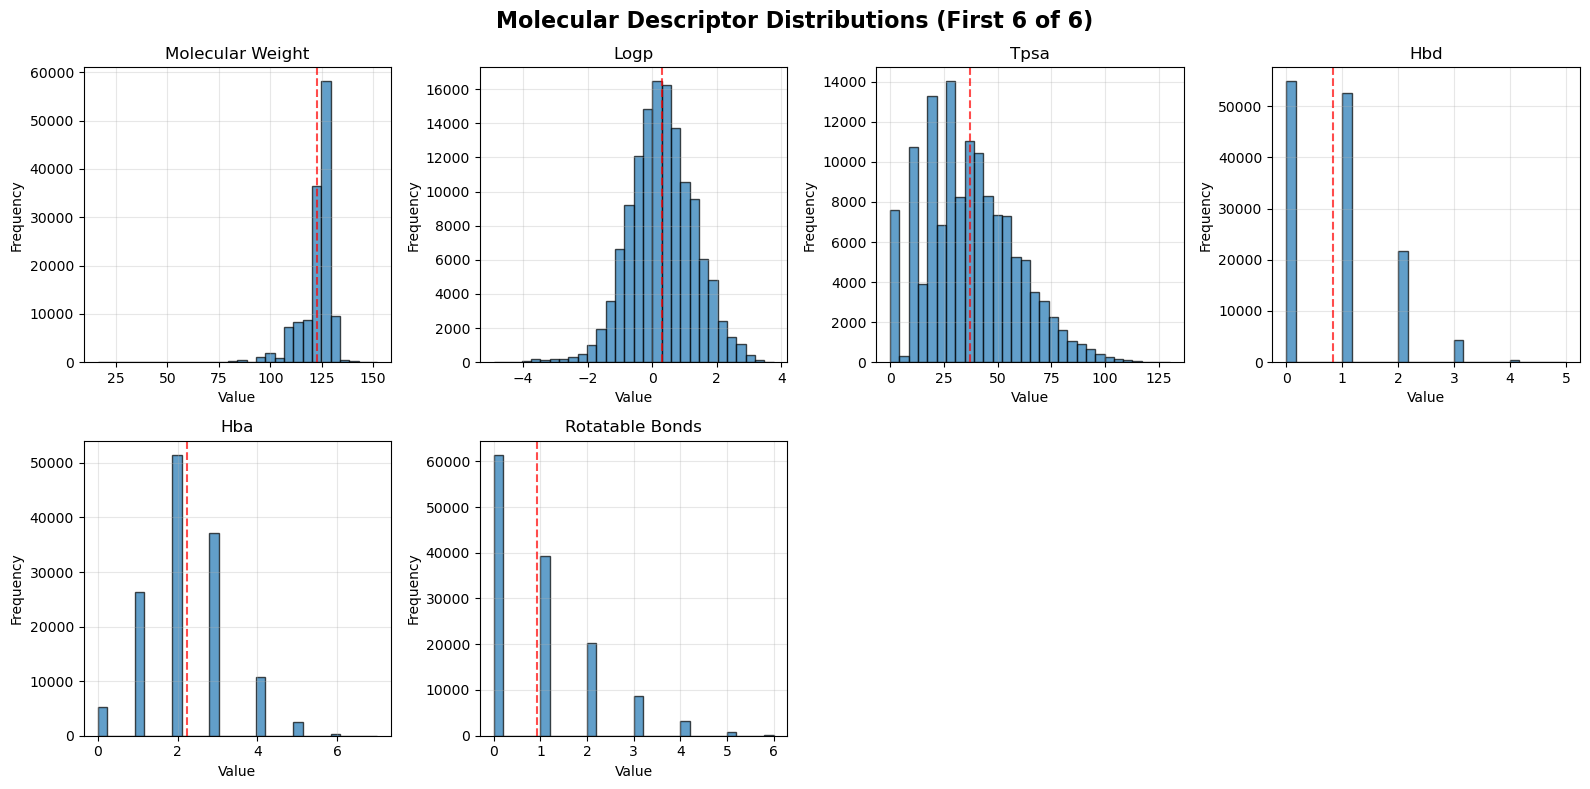


Feature matrix created:
  Shape: (133885, 6)
  Data type: float64
  Memory usage: 6.13 MB

Feature ranges (first 10 descriptors):
  molecular_weight: 16.04 to 152.04 (mean: 122.76)
  logp: -4.91 to 3.76 (mean: 0.30)
  tpsa: 0.00 to 130.12 (mean: 37.16)
  hbd: 0.00 to 5.00 (mean: 0.83)
  hba: 0.00 to 7.00 (mean: 2.23)
  rotatable_bonds: 0.00 to 6.00 (mean: 0.92)


In [ ]:
# Get all descriptor columns (excluding ID and SMILES columns)
descriptor_columns = [col for col in combined_df.columns if col not in ['gdb_id', 'smiles', 'canonical_smiles']]

# Use polars for efficient data cleaning
clean_df_pl = combined_df_pl.drop_nulls(subset=descriptor_columns)
clean_df = clean_df_pl.to_pandas().reset_index(drop=True)
print(f"Clean dataset for clustering: {len(clean_df)} molecules")
print(f"Total number of descriptors: {len(descriptor_columns)}")
print(f"Descriptor names: {descriptor_columns}")

# Show some key statistics about the feature space
print(f"\nFeature Space Information:")
print(f"Number of samples (molecules): {len(clean_df)}")
print(f"Number of features (descriptors): {len(descriptor_columns)}")
print(f"Feature vector shape: ({len(clean_df)}, {len(descriptor_columns)})")

# Visualize distributions of key descriptors
key_descriptors = descriptor_columns[:12]  # Show first 12 descriptors
n_descriptors = len(key_descriptors)
n_cols = 4
n_rows = (n_descriptors + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten() if n_rows > 1 else axes if n_rows == 1 else [axes]

for i, desc in enumerate(key_descriptors):
    data = clean_df[desc].dropna()
    
    if len(data) > 0:
        axes[i].hist(data, bins=30, alpha=0.7, edgecolor='black')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
        axes[i].set_title(f'{desc.replace("_", " ").title()}')
        axes[i].grid(True, alpha=0.3)
        
        # Add mean line
        mean_val = data.mean()
        axes[i].axvline(mean_val, color='red', linestyle='--', alpha=0.7)
    else:
        axes[i].text(0.5, 0.5, 'No data', transform=axes[i].transAxes, ha='center', va='center')
        axes[i].set_title(f'{desc} (No Data)')

# Hide unused subplots
for i in range(len(key_descriptors), len(axes)):
    axes[i].set_visible(False)

plt.suptitle(f'Molecular Descriptor Distributions (First {len(key_descriptors)} of {len(descriptor_columns)})', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Prepare feature matrix for clustering (all descriptors)
feature_matrix = clean_df[descriptor_columns].values
print(f"\nFeature matrix created:")
print(f"  Shape: {feature_matrix.shape}")
print(f"  Data type: {feature_matrix.dtype}")
print(f"  Memory usage: {feature_matrix.nbytes / 1024 / 1024:.2f} MB")

# Show feature ranges
print(f"\nFeature ranges (first 10 descriptors):")
for i, desc in enumerate(descriptor_columns[:10]):
    min_val = clean_df[desc].min()
    max_val = clean_df[desc].max()
    mean_val = clean_df[desc].mean()
    print(f"  {desc}: {min_val:.2f} to {max_val:.2f} (mean: {mean_val:.2f})")

if len(descriptor_columns) > 10:
    print(f"  ... and {len(descriptor_columns) - 10} more descriptors")

### **5. Data Preparation for Clustering**

Standardize the features for optimal clustering performance.

In [ ]:
# Standardize features for clustering
scaler = StandardScaler()
features_scaled = scaler.fit_transform(feature_matrix)

print("Feature standardization completed")
print(f"Scaled features shape: {features_scaled.shape}")
print(f"\nScaled feature statistics:")
print(f"  Mean: {features_scaled.mean(axis=0)}")
print(f"  Std: {features_scaled.std(axis=0)}")

# Create DataFrame with scaled features for easier handling
scaled_df = clean_df.copy()
scaled_df['logp_scaled'] = features_scaled[:, 0]
scaled_df['tpsa_scaled'] = features_scaled[:, 1]

print("\nData ready for clustering analysis")

Feature standardization completed
Scaled features shape: (133885, 6)

Scaled feature statistics:
  Mean: [-1.60656905e-15 -5.43448304e-17 -1.76620699e-16  9.68017291e-17
  8.49137975e-17 -4.07586228e-17]
  Std: [1. 1. 1. 1. 1. 1.]

Data ready for clustering analysis


### **6. K-Means Clustering**

Apply K-Means clustering algorithm to group molecules based on their descriptors.

Finding optimal number of clusters for K-Means (elbow)...


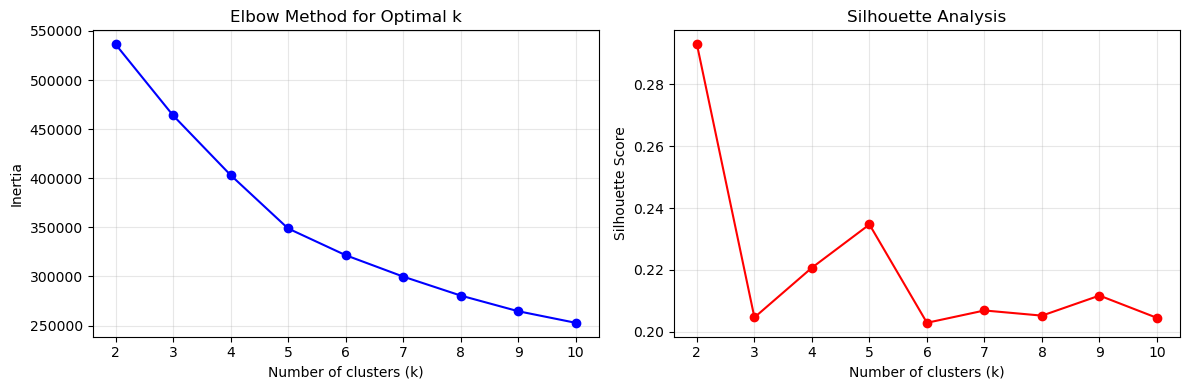

Optimal number of clusters: 2
Best silhouette score: 0.293

K-Means clustering completed
Cluster distribution:
  Cluster 0: 76450 molecules (57.1%)
  Cluster 1: 57435 molecules (42.9%)


In [ ]:
# Determine optimal number of clusters using elbow method
k_range = range(2, 11)
inertias = []
silhouette_scores = []

print("Finding optimal number of clusters for K-Means (elbow)...")
for k in tqdm(k_range, desc="K-Means optimization"):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_) ### Could limit k_range iteration depending on inertia behavior
    ### low inertia diff (k, k-1, ..., k-n) --> stable silhouette scores --> no need to increase k further
    sil_score = silhouette_score(features_scaled, kmeans.labels_)
    silhouette_scores.append(sil_score)

# Plot elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow curve
axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(k_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Select optimal k (highest silhouette score)
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {optimal_k}")
print(f"Best silhouette score: {max(silhouette_scores):.3f}")

# Apply K-Means with optimal k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(features_scaled)

# Add cluster labels to dataframe
scaled_df['kmeans_cluster'] = kmeans_labels

# K-Means clustering completed")
print(f"Cluster distribution:")
# Use polars for efficient value counting
cluster_counts_pl = pl.DataFrame({'cluster': kmeans_labels}).group_by('cluster').len().sort('cluster')
cluster_counts_dict = dict(zip(cluster_counts_pl['cluster'], cluster_counts_pl['len']))
for cluster, count in cluster_counts_dict.items():
    percentage = (count / len(kmeans_labels)) * 100
    print(f"  Cluster {cluster}: {count} molecules ({percentage:.1f}%)")

### **7. DBSCAN Clustering**

Apply DBSCAN clustering algorithm as a density-based alternative approach.

In [ ]:
# DBSCAN with Memory Management - Use Sampling Approach
print(f"Original dataset size: {len(features_scaled)} molecules")
print("Using sampling approach to prevent memory issues with DBSCAN...")

# Sample a subset for DBSCAN (50,000 molecules or 50% of dataset, whichever is smaller)
sample_size = min(50000, int(0.5 * len(features_scaled)), len(features_scaled))
np.random.seed(42)  # For reproducibility                                 k can't be selected multiple times
sample_indices = np.random.choice(len(features_scaled), size=sample_size, replace=False)

# Create sample dataset using polars for efficiency
features_sample = features_scaled[sample_indices]
# Create polars dataframe with row indices and filter
clean_df_with_idx_pl = clean_df_pl.with_row_count('row_idx')
clean_df_sample_pl = clean_df_with_idx_pl.filter(pl.col('row_idx').is_in(sample_indices)).drop('row_idx')
clean_df_sample = clean_df_sample_pl.to_pandas().reset_index(drop=True)

print(f"Sample size for DBSCAN: {len(features_sample)} molecules")

Original dataset size: 133885 molecules
Using sampling approach to prevent memory issues with DBSCAN...
Sample size for DBSCAN: 50000 molecules


### **7.1. Sample Representativeness Validation**

Validate that the sample is statistically representative (using Kolmogorov-Smirnov Test) of the full dataset before proceeding with DBSCAN clustering.

Sample Quality Assessment:
Statistical Comparison (Full Dataset vs Sample):
Descriptor           Full Mean    Sample Mean  Diff %     Full Std     Sample Std  
--------------------------------------------------------------------------------


Comparing distributions: 100%|██████████| 6/6 [00:00<00:00, 1694.78it/s]


molecular_weight     122.765      122.757      0.01       7.565        7.560       
logp                 0.297        0.297        0.19       1.001        1.000       
tpsa                 37.164       37.055       0.29       21.245       21.201      
hbd                  0.828        0.823        0.56       0.838        0.836       
hba                  2.232        2.230        0.10       1.055        1.057       
rotatable_bonds      0.923        0.919        0.48       1.091        1.089       

Kolmogorov-Smirnov Test (p-value > 0.05 = good sample):


KS tests: 100%|██████████| 6/6 [00:00<00:00, 178.16it/s]

  molecular_weight    : p-value = 0.8875 (✓ Good)
  logp                : p-value = 0.9914 (✓ Good)
  tpsa                : p-value = 0.6644 (✓ Good)
  hbd                 : p-value = 0.9778 (✓ Good)
  hba                 : p-value = 0.9998 (✓ Good)
  rotatable_bonds     : p-value = 0.9967 (✓ Good)

Sample Quality Summary:
  Descriptors with good distribution match: 6/6
  Sample quality score: 100.0%
  Sample is highly representative of the full dataset


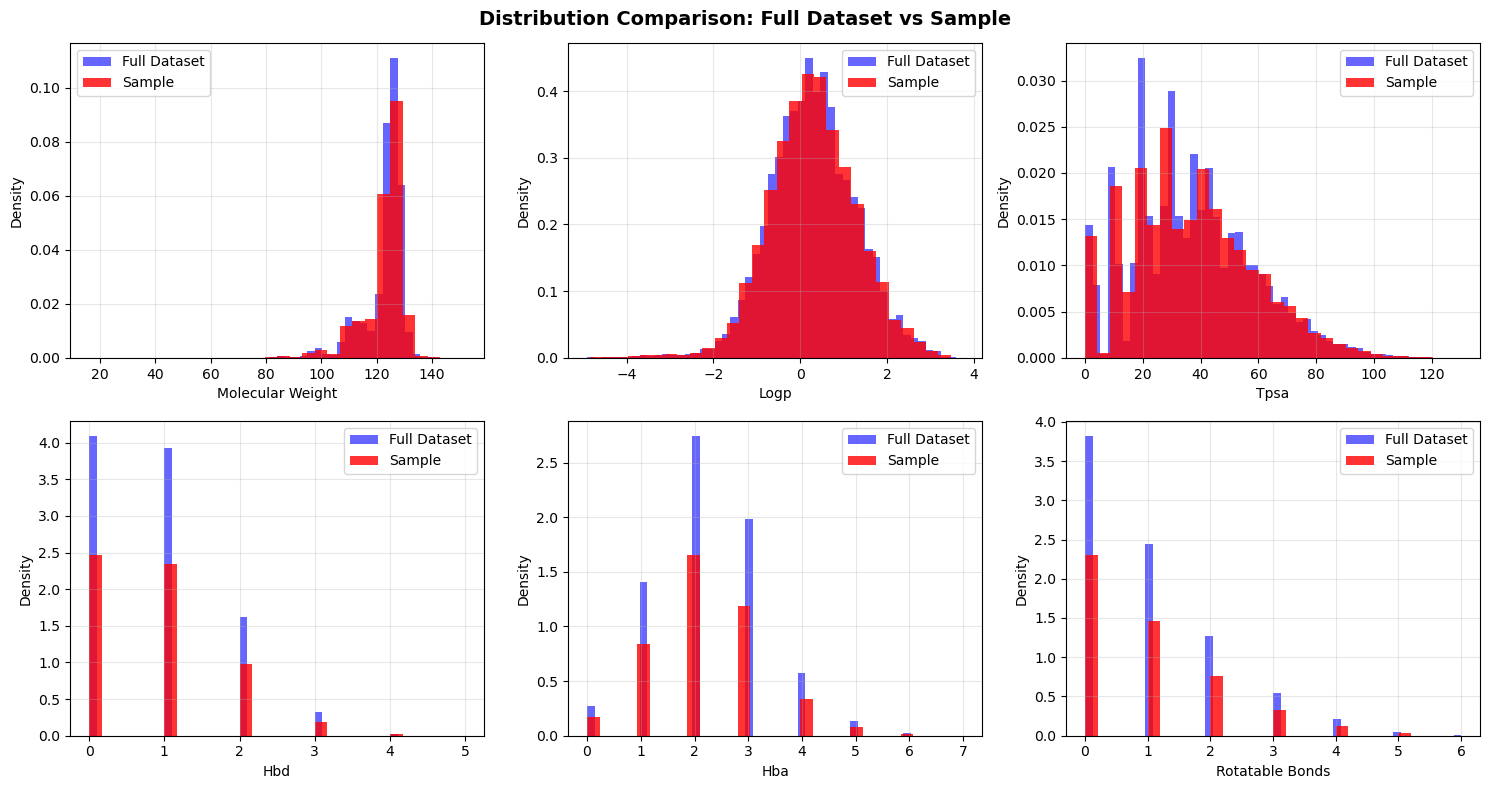

In [ ]:
# Validate sample representativeness
print(f"Sample Quality Assessment:")
print("=" * 40)

# Compare distributions of each descriptor
descriptor_names = ['molecular_weight', 'logp', 'tpsa', 'hbd', 'hba', 'rotatable_bonds']

print("Statistical Comparison (Full Dataset vs Sample):")
print(f"{'Descriptor':<20} {'Full Mean':<12} {'Sample Mean':<12} {'Diff %':<10} {'Full Std':<12} {'Sample Std':<12}")
print("-" * 80)

for i, desc in enumerate(tqdm(descriptor_names, desc="Comparing distributions")):
    full_mean = clean_df[desc].mean()
    sample_mean = clean_df_sample[desc].mean()
    full_std = clean_df[desc].std()
    sample_std = clean_df_sample[desc].std()
    
    # Calculate percentage difference in means
    diff_percent = abs((sample_mean - full_mean) / full_mean) * 100 if full_mean != 0 else 0
    
    print(f"{desc:<20} {full_mean:<12.3f} {sample_mean:<12.3f} {diff_percent:<10.2f} {full_std:<12.3f} {sample_std:<12.3f}")

# Statistical tests for representativeness
print(f"\nKolmogorov-Smirnov Test (p-value > 0.05 = good sample):")
ks_results = []
for desc in tqdm(descriptor_names, desc="KS tests"):
    full_data = clean_df[desc].values
    sample_data = clean_df_sample[desc].values
    
    # KS test: null hypothesis = distributions are the same
    ks_stat, p_value = stats.ks_2samp(full_data, sample_data)
    ks_results.append(p_value)
    
    status = "✓ Good" if p_value > 0.05 else "⚠ Warning"
    print(f"  {desc:<20}: p-value = {p_value:.4f} ({status})")

# Overall assessment
good_samples = sum(1 for p in ks_results if p > 0.05)
total_descriptors = len(ks_results)
sample_quality = good_samples / total_descriptors

print(f"\nSample Quality Summary:")
print(f"  Descriptors with good distribution match: {good_samples}/{total_descriptors}")
print(f"  Sample quality score: {sample_quality:.1%}")

if sample_quality >= 0.8:
    print("  Sample is highly representative of the full dataset")
elif sample_quality >= 0.6:
    print("  Sample is moderately representative")
else:
    print("  Sample may not be representative (consider larger sample)")

# Visualize sample vs full distribution for key descriptors
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, desc in enumerate(descriptor_names):
    axes[i].hist(clean_df[desc], bins=50, alpha=0.6, label='Full Dataset', density=True, color='blue')
    axes[i].hist(clean_df_sample[desc], bins=30, alpha=0.8, label='Sample', density=True, color='red')
    axes[i].set_xlabel(desc.replace('_', ' ').title())
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribution Comparison: Full Dataset vs Sample', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### **7.2. DBSCAN Parameter Optimization**

Optimize DBSCAN parameters using the validated sample and apply the clustering algorithm.

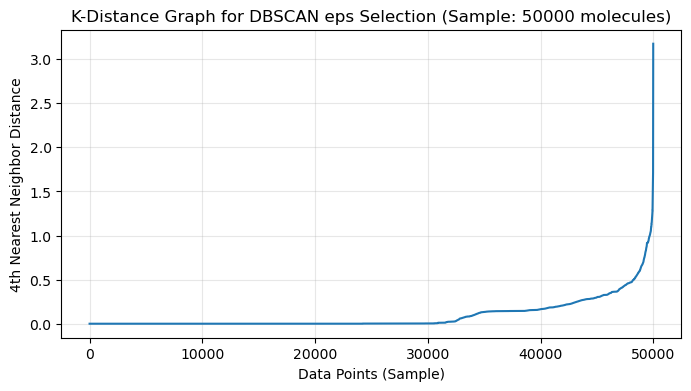

Optimizing DBSCAN parameters on sample...


DBSCAN optimization:  40%|████      | 6/15 [00:57<01:28,  9.82s/it]

In [ ]:
# Find optimal eps using k-distance graph on sample
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(features_sample)
distances, indices = neighbors_fit.kneighbors(features_sample)
distances = np.sort(distances[:, 3], axis=0)

# Plot k-distance graph
plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.xlabel('Data Points (Sample)')
plt.ylabel('4th Nearest Neighbor Distance')
plt.title(f'K-Distance Graph for DBSCAN eps Selection (Sample: {sample_size} molecules)')
plt.grid(True, alpha=0.3)
plt.show()

# Try different eps values on sample
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5]  # Adjusted for 6D space
min_samples_values = [5, 10, 15]

best_score = -1
best_params = {}
results = []

print("Optimizing DBSCAN parameters on sample...")
# Create all parameter combinations for progress bar
param_combinations = [(eps, min_samples) for eps in eps_values for min_samples in min_samples_values]

for eps, min_samples in tqdm(param_combinations, desc="DBSCAN optimization"):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(features_sample)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    if n_clusters > 1:  # Need at least 2 clusters for silhouette score
        try:
            sil_score = silhouette_score(features_sample, labels)
            results.append({
                'eps': eps, 'min_samples': min_samples,
                'n_clusters': n_clusters, 'n_noise': n_noise,
                'silhouette': sil_score
            })
            
            if sil_score > best_score:
                best_score = sil_score
                best_params = {'eps': eps, 'min_samples': min_samples}
        except:
            pass

# Display results using polars for better performance
results_df_pl = pl.DataFrame(results)
results_df = results_df_pl.to_pandas()
print(f"\nDBSCAN parameter optimization results (on sample):")
print(results_df.round(3))

# Apply DBSCAN with best parameters on SAMPLE ONLY
if best_params:
    print(f"\nBest parameters: eps={best_params['eps']}, min_samples={best_params['min_samples']}")
    print(f"Best silhouette score: {best_score:.3f}")
    
    dbscan_final = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples'])
    dbscan_labels_sample = dbscan_final.fit_predict(features_sample)
else: 
    # Fallback parameters
    print(f"\nUsing fallback parameters: eps=1.0, min_samples=10")
    dbscan_final = DBSCAN(eps=1.0, min_samples=10)
    dbscan_labels_sample = dbscan_final.fit_predict(features_sample)

# Create DBSCAN results for sample only
scaled_df_sample = clean_df_sample.copy()
scaled_df_sample['dbscan_cluster'] = dbscan_labels_sample

# Analyze DBSCAN results on sample
n_clusters_dbscan = len(set(dbscan_labels_sample)) - (1 if -1 in dbscan_labels_sample else 0)
n_noise_dbscan = list(dbscan_labels_sample).count(-1)

print(f"\nDBSCAN clustering results (on sample of {sample_size} molecules):")
print(f"Number of clusters: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise_dbscan}")
print(f"Noise percentage: {(n_noise_dbscan/len(dbscan_labels_sample))*100:.1f}%")

if n_clusters_dbscan > 0:
    # Use polars for efficient value counting
    cluster_counts_pl = pl.DataFrame({'cluster': dbscan_labels_sample}).group_by('cluster').len().sort('cluster')
    cluster_counts_dict = dict(zip(cluster_counts_pl['cluster'], cluster_counts_pl['len']))
    print(f"\nCluster distribution:")
    for cluster, count in cluster_counts_dict.items():
        percentage = (count / len(dbscan_labels_sample)) * 100
        if cluster == -1:
            print(f"  Noise: {count} molecules ({percentage:.1f}%)")
        else:
            print(f"  Cluster {cluster}: {count} molecules ({percentage:.1f}%)")

print(f"\nNote: DBSCAN was run on a sample of {sample_size} molecules to prevent memory issues.")

### **8. Clustering Results Visualization and Comparison**

Compare the results of both clustering algorithms and analyze cluster characteristics.

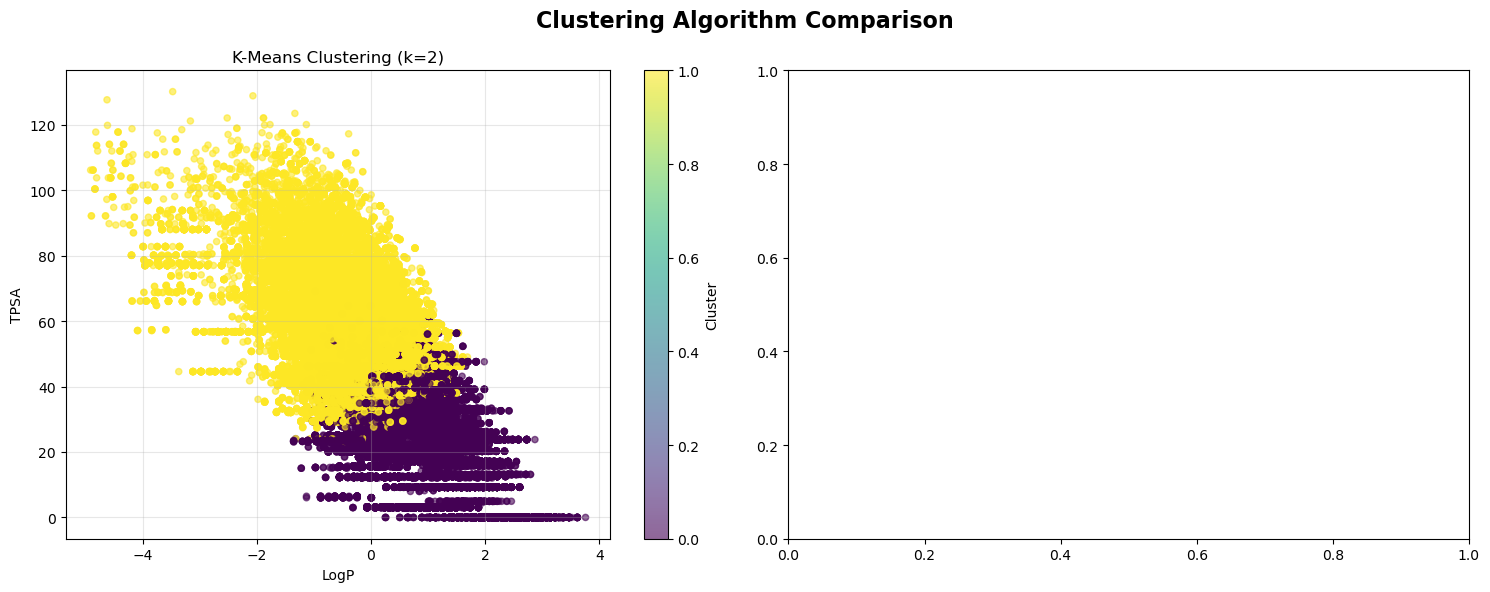

Clustering Algorithm Comparison:
K-Means (k=2):
  Silhouette Score: 0.293
  Calinski-Harabasz Score: 66593.859
  Number of clusters: 2
K-Means (k=2):
  Silhouette Score: 0.293
  Calinski-Harabasz Score: 66593.859
  Number of clusters: 2

Clustering results exported to: qm9_clustering_results.csv

Analysis completed successfully!
Dataset contains 133885 molecules with molecular descriptors and cluster assignments.

Clustering results exported to: qm9_clustering_results.csv

Analysis completed successfully!
Dataset contains 133885 molecules with molecular descriptors and cluster assignments.


In [ ]:
# Visualize clustering results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# K-Means results (full dataset)
scatter1 = axes[0].scatter(scaled_df['logp'], scaled_df['tpsa'], 
                          c=scaled_df['kmeans_cluster'], cmap='viridis', 
                          alpha=0.6, s=10)
axes[0].set_xlabel('LogP')
axes[0].set_ylabel('TPSA')
axes[0].set_title(f'K-Means Clustering (k={optimal_k}) - Full Dataset')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# DBSCAN results (sample only)
scatter2 = axes[1].scatter(scaled_df_sample['logp'], scaled_df_sample['tpsa'], 
                          c=scaled_df_sample['dbscan_cluster'], cmap='viridis', 
                          alpha=0.7, s=20)
axes[1].set_xlabel('LogP')
axes[1].set_ylabel('TPSA')
axes[1].set_title(f'DBSCAN Clustering - Sample ({sample_size} molecules)')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.suptitle('Clustering Algorithm Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Compare clustering performance
print("Clustering Algorithm Comparison:")
print("=" * 50)

# K-Means metrics (full dataset)
kmeans_silhouette = silhouette_score(features_scaled, kmeans_labels)
kmeans_calinski = calinski_harabasz_score(features_scaled, kmeans_labels)

print(f"K-Means (k={optimal_k}) - Full Dataset:")
print(f"  Dataset size: {len(features_scaled)} molecules")
print(f"  Silhouette Score: {kmeans_silhouette:.3f}")
print(f"  Calinski-Harabasz Score: {kmeans_calinski:.3f}")
print(f"  Number of clusters: {optimal_k}")

# DBSCAN metrics (sample only)
if n_clusters_dbscan > 1:
    # Remove noise points for metric calculation
    valid_indices = dbscan_labels_sample != -1
    if np.sum(valid_indices) > 0:
        dbscan_silhouette = silhouette_score(features_sample[valid_indices], 
                                           dbscan_labels_sample[valid_indices])
        dbscan_calinski = calinski_harabasz_score(features_sample[valid_indices], 
                                                dbscan_labels_sample[valid_indices])
        print(f"\nDBSCAN - Sample Dataset:")
        print(f"  Dataset size: {sample_size} molecules (sample)")
        print(f"  Silhouette Score: {dbscan_silhouette:.3f}")
        print(f"  Calinski-Harabasz Score: {dbscan_calinski:.3f}")
        print(f"  Number of clusters: {n_clusters_dbscan}")
        print(f"  Noise points: {n_noise_dbscan} ({(n_noise_dbscan/len(dbscan_labels_sample))*100:.1f}%)")
else:
    print(f"\nDBSCAN: Unable to form valid clusters with current parameters")

# Analyze cluster characteristics
print(f"\nCluster Characteristics Analysis:")
print("=" * 50)

# K-Means cluster analysis (full dataset)
print("K-Means Clusters (Full Dataset):")
for cluster in range(optimal_k):
    cluster_data = scaled_df[scaled_df['kmeans_cluster'] == cluster]
    print(f"  Cluster {cluster} (n={len(cluster_data)}):")
    print(f"    LogP: {cluster_data['logp'].mean():.2f} ± {cluster_data['logp'].std():.2f}")
    print(f"    TPSA: {cluster_data['tpsa'].mean():.2f} ± {cluster_data['tpsa'].std():.2f}")
    print(f"    Molecular Weight: {cluster_data['molecular_weight'].mean():.1f} ± {cluster_data['molecular_weight'].std():.1f}")

# DBSCAN cluster analysis (sample)
if n_clusters_dbscan > 0:
    print(f"\nDBSCAN Clusters (Sample Dataset):")
    for cluster in sorted(set(dbscan_labels_sample)):
        cluster_data = scaled_df_sample[scaled_df_sample['dbscan_cluster'] == cluster]
        if cluster == -1:
            print(f"  Noise points (n={len(cluster_data)}):")
        else:
            print(f"  Cluster {cluster} (n={len(cluster_data)}):")
        print(f"    LogP: {cluster_data['logp'].mean():.2f} ± {cluster_data['logp'].std():.2f}")
        print(f"    TPSA: {cluster_data['tpsa'].mean():.2f} ± {cluster_data['tpsa'].std():.2f}")
        print(f"    Molecular Weight: {cluster_data['molecular_weight'].mean():.1f} ± {cluster_data['molecular_weight'].std():.1f}")

# Export results using polars for better performance
output_file = 'qm9_clustering_results.csv'
# Convert final results to polars for efficient export
scaled_df_pl = pl.from_pandas(scaled_df)
scaled_df_pl.write_csv(output_file)
print(f"\nClustering results exported to: {output_file}")

print(f"\nAnalysis completed successfully!")
print(f"Dataset contains {len(scaled_df)} molecules with molecular descriptors and cluster assignments.")